# Notebook 01 — Lorenz System Simulation

## What is the Lorenz System?

The Lorenz system is a set of three coupled ordinary differential equations
introduced by Edward Lorenz in 1963 while modeling atmospheric convection.

$$\frac{dx}{dt} = \sigma(y - x)$$
$$\frac{dy}{dt} = x(\rho - z) - y$$
$$\frac{dz}{dt} = xy - \beta z$$

With classic parameters $\sigma=10$, $\rho=28$, $\beta=\frac{8}{3}$, the system
exhibits **deterministic chaos**: the trajectory never repeats, is exquisitely
sensitive to initial conditions, yet stays confined to a bounded region of space
called the **strange attractor**.

This notebook simulates the system, visualizes the attractor, and demonstrates
the core property we will later try to exploit with machine learning.

In [2]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Make src/ importable from the notebooks/ directory
sys.path.append(os.path.join(os.path.dirname(""), "..", "src"))

from simulate import simulate_lorenz
from visualize import plot_attractor_3d, plot_attractor_2d, plot_time_series

print("Imports successful.")

Imports successful.


## Simulating the System

We integrate the Lorenz ODEs numerically over 50 time units with 10,000 steps.
The solver used internally is LSODA (via `scipy.integrate.odeint`), an adaptive
step-size method suitable for potentially stiff systems.

In [3]:
t, trajectory = simulate_lorenz(
    initial_state=[0.0, 1.0, 0.0],
    t_end=50.0,
    n_steps=10000,
)

print(f"Trajectory shape : {trajectory.shape}")
print(f"Time range       : {t[0]:.1f} → {t[-1]:.1f}")
print(f"X range          : {trajectory[:,0].min():.2f} → {trajectory[:,0].max():.2f}")
print(f"Y range          : {trajectory[:,1].min():.2f} → {trajectory[:,1].max():.2f}")
print(f"Z range          : {trajectory[:,2].min():.2f} → {trajectory[:,2].max():.2f}")

Trajectory shape : (10000, 3)
Time range       : 0.0 → 50.0
X range          : -18.30 → 19.82
Y range          : -24.75 → 27.69
Z range          : 0.00 → 48.37


## The Strange Attractor in 3D

The trajectory never crosses itself and never repeats — yet it stays
confined to this butterfly-shaped region forever. This is the strange attractor.
Color encodes time: early timesteps are dark blue, late timesteps are yellow/red.

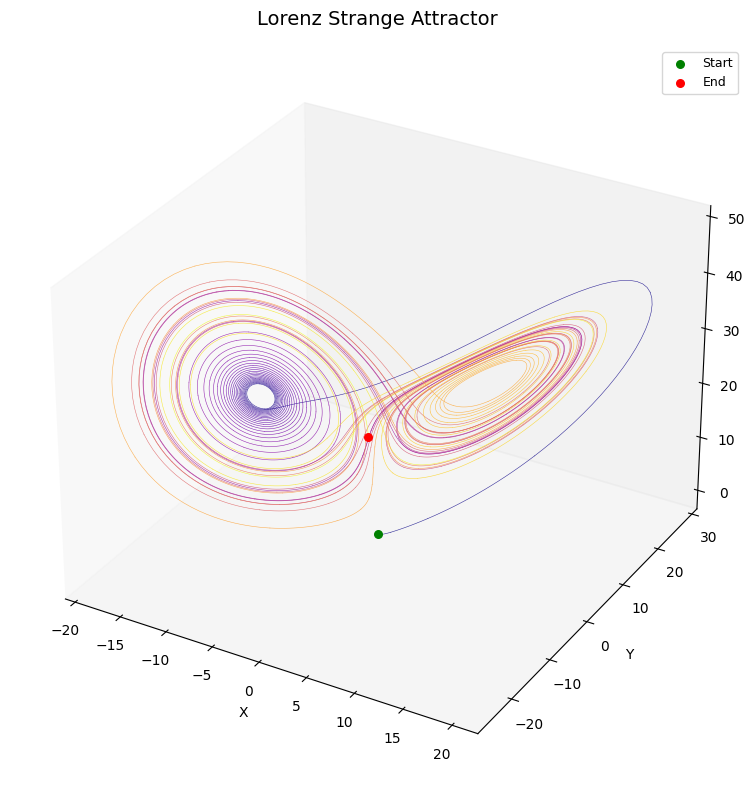

In [4]:
plot_attractor_3d(trajectory, title="Lorenz Strange Attractor")

## 2D Projections

Each projection reveals a different cross-section of the attractor's geometry.

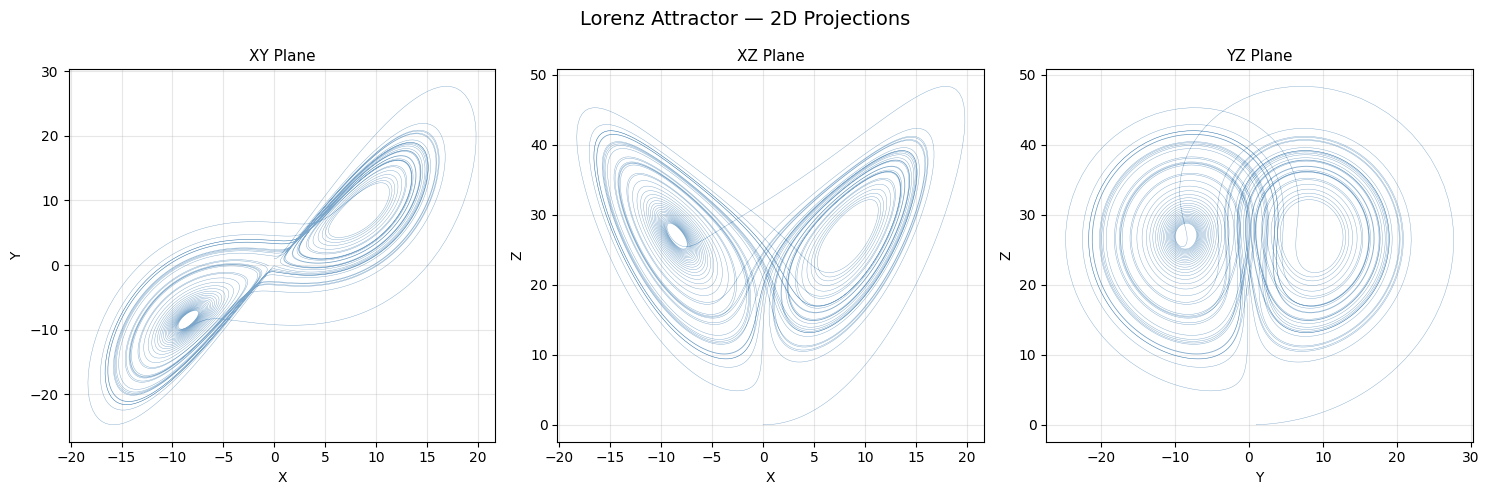

In [5]:
plot_attractor_2d(trajectory)

## Time Series — Chaos in the Time Domain

Each coordinate oscillates irregularly. There is no repeating period.
This is the fingerprint of chaos — deterministic but unpredictable.

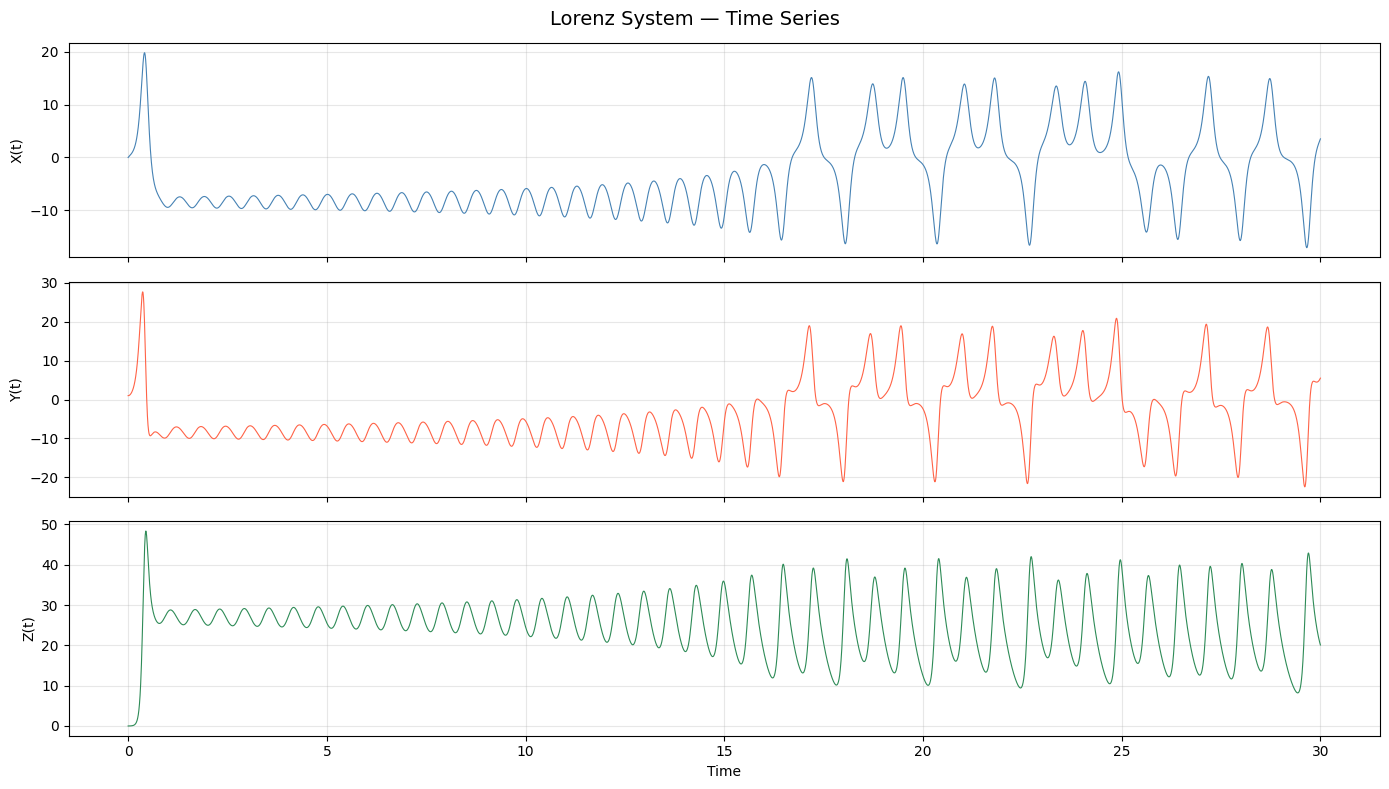

In [6]:
plot_time_series(t, trajectory, t_max=30.0)

## Sensitive Dependence on Initial Conditions

The most famous property of chaos: two trajectories starting almost identically
will diverge exponentially. We demonstrate this now by perturbing the initial
condition by a tiny amount — $\epsilon = 1 \times 10^{-5}$.

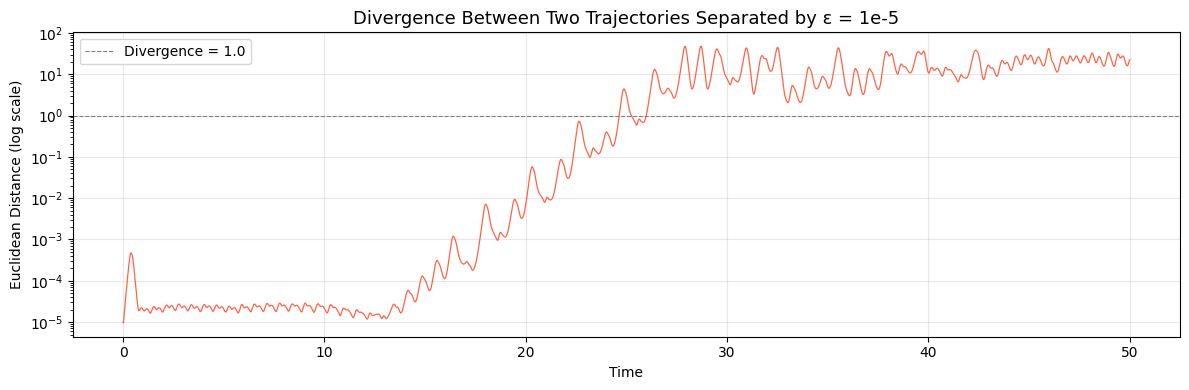

Trajectories diverge beyond 1.0 at t ≈ 24.64


In [7]:
epsilon = 1e-5

t, traj_original = simulate_lorenz(initial_state=[0.0, 1.0, 0.0])
_, traj_perturbed = simulate_lorenz(initial_state=[0.0 + epsilon, 1.0, 0.0])

# Compute Euclidean distance between trajectories at each time step
divergence = np.sqrt(np.sum((traj_original - traj_perturbed) ** 2, axis=1))

plt.figure(figsize=(12, 4))
plt.semilogy(t, divergence, color="tomato", linewidth=0.9)
plt.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8, label="Divergence = 1.0")
plt.title("Divergence Between Two Trajectories Separated by ε = 1e-5", fontsize=13)
plt.xlabel("Time")
plt.ylabel("Euclidean Distance (log scale)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find when divergence first exceeds 1.0
threshold_idx = np.argmax(divergence > 1.0)
print(f"Trajectories diverge beyond 1.0 at t ≈ {t[threshold_idx]:.2f}")

## Key Takeaway

Two trajectories separated by only $10^{-5}$ become completely uncorrelated
within roughly **t ≈ 20–25 time units**. This is not a failure of the solver —
it is the mathematical reality of chaos.

This divergence time is governed by the **Lyapunov exponent**, which we will
compute formally in the next notebook. It sets the **theoretical ceiling** for
how far into the future any model — no matter how powerful — can predict.

This is what makes the ML challenge in this project meaningful:
we are not just building a predictor, we are measuring where prediction
fundamentally breaks down.